In [10]:
import numpy
import pandas as pd

In [11]:
path="electric_vehicles_dataset.csv"
data=pd.read_csv(path,encoding='latin-1')
data.head()

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,NaN,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3
2,3,NIO,ET7,2020,Calcium-ion,64.7,235,Level 2 Charging,8.9,94347.37,Beige,UK,5.0,0.0,5.0,6300,5
3,4,Audi,e-tron,2025,Lithium-iron phosphate,120.5,140,Ultra-Fast Charging (350 kW+),10.5,75615.15,Sunset Orange,Argentina,2.0,0.0,5.0,2339,5
4,5,Acura,ZDX (with GM Ultium),2023,Lithium-titanate,51.8,336,Plug-in Hydrogen Refueling,3.6,141046.94,Ice Silver,United Arab Emirates,2.0,0.0,3.0,1051,4


In [12]:
data.shape

(3022, 17)

In [14]:
data.isnull().sum()

Vehicle_ID                  0
Manufacturer                0
Model                       0
Year                        0
Battery_Type                0
Battery_Capacity_kWh        0
Range_km                    0
Charging_Type               0
Charge_Time_hr              0
Price_USD                   0
Color                       0
Country_of_Manufacture      0
Autonomous_Level          442
CO2_Emissions_g_per_km    592
Safety_Rating             337
Units_Sold_2024             0
Warranty_Years              0
dtype: int64

In [17]:
data['CO2_Emissions_g_per_km'] = data['CO2_Emissions_g_per_km'].fillna(0)

In [18]:
data['Autonomous_Level'] = data['Autonomous_Level'].fillna(0)

In [19]:
data['Safety_Rating'] = data['Safety_Rating'].fillna(data['Safety_Rating'].median())

In [20]:
print(data[['CO2_Emissions_g_per_km', 'Autonomous_Level', 'Safety_Rating']].isnull().sum())

CO2_Emissions_g_per_km    0
Autonomous_Level          0
Safety_Rating             0
dtype: int64


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              3022 non-null   int64  
 1   Manufacturer            3022 non-null   object 
 2   Model                   3022 non-null   object 
 3   Year                    3022 non-null   int64  
 4   Battery_Type            3022 non-null   object 
 5   Battery_Capacity_kWh    3022 non-null   float64
 6   Range_km                3022 non-null   int64  
 7   Charging_Type           3022 non-null   object 
 8   Charge_Time_hr          3022 non-null   float64
 9   Price_USD               3022 non-null   float64
 10  Color                   3022 non-null   object 
 11  Country_of_Manufacture  3022 non-null   object 
 12  Autonomous_Level        3022 non-null   float64
 13  CO2_Emissions_g_per_km  3022 non-null   float64
 14  Safety_Rating           3022 non-null   

In [22]:
data.head(2)

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,0.0,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3


In [23]:
data.corr()['Price_USD']

ValueError: could not convert string to float: 'Acura'

In [25]:
correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix['Price_USD'].sort_values(ascending=False))

Price_USD                 1.000000
Warranty_Years            0.039806
Vehicle_ID                0.035637
Safety_Rating             0.005929
Autonomous_Level          0.005760
Range_km                 -0.007748
Units_Sold_2024          -0.013324
Charge_Time_hr           -0.013851
Battery_Capacity_kWh     -0.017496
Year                     -0.031727
CO2_Emissions_g_per_km         NaN
Name: Price_USD, dtype: float64


In [28]:
data['Model'].value_counts

<bound method IndexOpsMixin.value_counts of 0                 ZDX (with GM Ultium)
1                      Revuelto (PHEV)
2                                  ET7
3                               e-tron
4                 ZDX (with GM Ultium)
                     ...              
3017              SF90 Stradale (PHEV)
3018    Born Electric (upcoming range)
3019                             Lyriq
3020                            XUV400
3021                      MG4 Electric
Name: Model, Length: 3022, dtype: object>

In [29]:
len(data['Model'].value_counts())

181

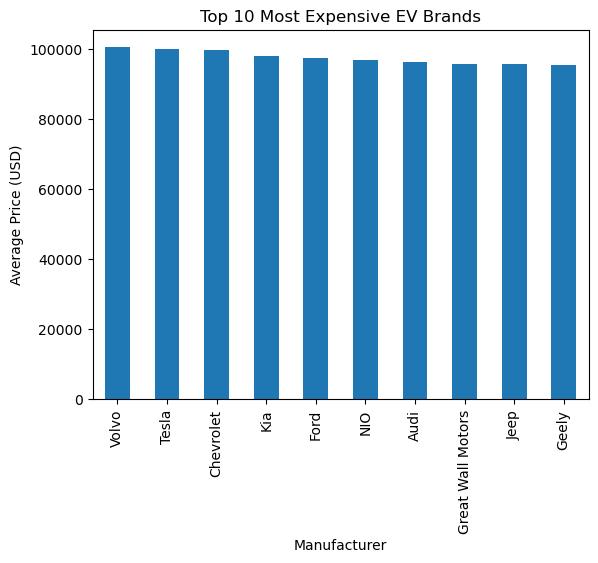

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Show top 10 most expensive manufacturers
avg_price = data.groupby('Manufacturer')['Price_USD'].mean().sort_values(ascending=False).head(10)
avg_price.plot(kind='bar', title='Top 10 Most Expensive EV Brands')
plt.ylabel('Average Price (USD)')
plt.show()

In [31]:
# 1. Target Encoding for 'Manufacturer'
# This replaces the name with the average price of that brand
data['Manufacturer_Encoded'] = data.groupby('Manufacturer')['Price_USD'].transform('mean')

# 2. Target Encoding for 'Model'
# This replaces the model name with the average price of that specific car
data['Model_Encoded'] = data.groupby('Model')['Price_USD'].transform('mean')

# 3. Drop the original text columns and the ID (the model can't read text)
data_final = data.drop(['Vehicle_ID', 'Manufacturer', 'Model', 'Color', 'Battery_Type', 'Charging_Type', 'Country_of_Manufacture'], axis=1)

# Now check your new correlation!
print(data_final.corr()['Price_USD'].sort_values(ascending=False))

Price_USD                 1.000000
Model_Encoded             0.230978
Manufacturer_Encoded      0.136289
Warranty_Years            0.039806
Safety_Rating             0.005929
Autonomous_Level          0.005760
Range_km                 -0.007748
Units_Sold_2024          -0.013324
Charge_Time_hr           -0.013851
Battery_Capacity_kWh     -0.017496
Year                     -0.031727
CO2_Emissions_g_per_km         NaN
Name: Price_USD, dtype: float64


In [32]:
data.head(2)

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years,Manufacturer_Encoded,Model_Encoded
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,0.0,5.0,19726,3,93420.143455,93420.143455
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3,87949.914677,85739.499091


In [33]:
import pandas as pd

# 1. Fix Nulls first (using your variable name 'data')
data['CO2_Emissions_g_per_km'] = data['CO2_Emissions_g_per_km'].fillna(0)
data['Autonomous_Level'] = data['Autonomous_Level'].fillna(0)
data['Safety_Rating'] = data['Safety_Rating'].fillna(data['Safety_Rating'].median())

# 2. Encode Manufacturer and Model (Target Encoding)
data['Manufacturer_Enc'] = data.groupby('Manufacturer')['Price_USD'].transform('mean')
data['Model_Enc'] = data.groupby('Model')['Price_USD'].transform('mean')

# 3. Encode Battery_Type (One-Hot Encoding)
# This creates columns like 'Battery_Type_Lithium-ion', 'Battery_Type_LFP', etc.
data = pd.get_dummies(data, columns=['Battery_Type'], prefix='Battery')

# 4. Drop the columns we no longer need
# We drop the original text and things that don't help prediction
cols_to_drop = ['Vehicle_ID', 'Manufacturer', 'Model', 'Color', 
                'Charging_Type', 'Country_of_Manufacture']
data_final = data.drop(columns=cols_to_drop)

# 5. Check the results
print("New Columns:", data_final.columns.tolist())
print("\nCorrelation with Price:")
print(data_final.corr()['Price_USD'].sort_values(ascending=False))

New Columns: ['Year', 'Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr', 'Price_USD', 'Autonomous_Level', 'CO2_Emissions_g_per_km', 'Safety_Rating', 'Units_Sold_2024', 'Warranty_Years', 'Manufacturer_Encoded', 'Model_Encoded', 'Manufacturer_Enc', 'Model_Enc', 'Battery_Aluminum-ion', 'Battery_Calcium-ion', 'Battery_Flow batteries', 'Battery_Lead-acid', 'Battery_Lithium-ion', 'Battery_Lithium-iron phosphate', 'Battery_Lithium-sulfur', 'Battery_Lithium-titanate', 'Battery_Magnesium-ion', 'Battery_Nickel-cobalt-aluminum', 'Battery_Nickel-manganese-cobalt', 'Battery_Nickel-metal hydride', 'Battery_Sodium-ion', 'Battery_Solid-state', 'Battery_Zinc-air']

Correlation with Price:
Price_USD                          1.000000
Model_Encoded                      0.230978
Model_Enc                          0.230978
Manufacturer_Enc                   0.136289
Manufacturer_Encoded               0.136289
Warranty_Years                     0.039806
Battery_Lithium-ion                0.021900
Battery_

In [34]:
data.head(2)

,Vehicle_ID,Manufacturer,Model,Year,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,...,Battery_Lithium-iron phosphate,Battery_Lithium-sulfur,Battery_Lithium-titanate,Battery_Magnesium-ion,Battery_Nickel-cobalt-aluminum,Battery_Nickel-manganese-cobalt,Battery_Nickel-metal hydride,Battery_Sodium-ion,Battery_Solid-state,Battery_Zinc-air
0,1,Acura,ZDX (with GM Ultium),2015,55.8,214,CHAdeMO,9.0,111203.94,Matte White,...,False,False,True,False,False,False,False,False,False,False
1,2,Lamborghini,Revuelto (PHEV),2025,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,...,False,False,True,False,False,False,False,False,False,False


In [35]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Charging Type: One-Hot Encoding
# This creates 1/0 columns for each charger (CCS, NACS, etc.)
data = pd.get_dummies(data, columns=['Charging_Type'], prefix='Charge')

# 2. Color: Label Encoding
# This turns 'Red', 'Blue', 'Black' into 1, 2, 3...
le = LabelEncoder()
data['Color_Encoded'] = le.fit_transform(data['Color'])

# 3. Final Cleanup
# We drop the original 'Color' column because we have 'Color_Encoded'
# Charging_Type is already gone because get_dummies removes the original
data_final = data.drop(columns=['Color'])

# 4. Check the results
print("Current columns in your dataset:")
print(data_final.columns.tolist())

# Check if Color or Charging now shows a high correlation with Price
print("\nNew Correlation check:")
print(data_final.corr(numeric_only=True)['Price_USD'].sort_values(ascending=False))

Current columns in your dataset:
['Vehicle_ID', 'Manufacturer', 'Model', 'Year', 'Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr', 'Price_USD', 'Country_of_Manufacture', 'Autonomous_Level', 'CO2_Emissions_g_per_km', 'Safety_Rating', 'Units_Sold_2024', 'Warranty_Years', 'Manufacturer_Encoded', 'Model_Encoded', 'Manufacturer_Enc', 'Model_Enc', 'Battery_Aluminum-ion', 'Battery_Calcium-ion', 'Battery_Flow batteries', 'Battery_Lead-acid', 'Battery_Lithium-ion', 'Battery_Lithium-iron phosphate', 'Battery_Lithium-sulfur', 'Battery_Lithium-titanate', 'Battery_Magnesium-ion', 'Battery_Nickel-cobalt-aluminum', 'Battery_Nickel-manganese-cobalt', 'Battery_Nickel-metal hydride', 'Battery_Sodium-ion', 'Battery_Solid-state', 'Battery_Zinc-air', 'Charge_Battery Swapping', 'Charge_CCS', 'Charge_CHAdeMO', 'Charge_DC Fast Charging (DCFC)', 'Charge_Inductive (Wireless) Charging', 'Charge_Level 1 Charging', 'Charge_Level 2 Charging', 'Charge_Mobile Charging', 'Charge_NACS', 'Charge_Overhead Pantograph 

In [36]:
data.head(2)

,Vehicle_ID,Manufacturer,Model,Year,Battery_Capacity_kWh,Range_km,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,...,Charge_Mobile Charging,Charge_NACS,Charge_Overhead Pantograph Charging,Charge_Plug-in Hydrogen Refueling,Charge_Solar Charging,Charge_Ultra-Fast Charging (350 kW+),Charge_Vehicle-to-Grid (V2G),Charge_Vehicle-to-Home (V2H),Charge_Vehicle-to-Load (V2L),Color_Encoded
0,1,Acura,ZDX (with GM Ultium),2015,55.8,214,9.0,111203.94,Matte White,UK,...,False,False,False,False,False,False,False,False,False,30
1,2,Lamborghini,Revuelto (PHEV),2025,90.8,212,7.3,127131.65,White,Netherlands,...,False,False,False,False,False,False,False,True,False,53


In [40]:
# Drop all remaining text/unwanted columns in one go
data_final = data.drop(columns=[
    'Vehicle_ID', 
    'Manufacturer', 
    'Model', 
    'Color', 
    'Country_of_Manufacture'
])

In [41]:
data.head(2)

,Vehicle_ID,Manufacturer,Model,Year,Battery_Capacity_kWh,Range_km,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,...,Charge_Mobile Charging,Charge_NACS,Charge_Overhead Pantograph Charging,Charge_Plug-in Hydrogen Refueling,Charge_Solar Charging,Charge_Ultra-Fast Charging (350 kW+),Charge_Vehicle-to-Grid (V2G),Charge_Vehicle-to-Home (V2H),Charge_Vehicle-to-Load (V2L),Color_Encoded
0,1,Acura,ZDX (with GM Ultium),2015,55.8,214,9.0,111203.94,Matte White,UK,...,False,False,False,False,False,False,False,False,False,30
1,2,Lamborghini,Revuelto (PHEV),2025,90.8,212,7.3,127131.65,White,Netherlands,...,False,False,False,False,False,False,False,True,False,53


In [53]:
# Check for any remaining non-numeric columns
print("Text columns remaining:", data_final.select_dtypes(include=['object']).columns.tolist())

Text columns remaining: []


In [54]:
# Save the clean version to a NEW variable
data_final = data.drop(columns=['Vehicle_ID', 'Manufacturer', 'Model', 'Color', 'Country_of_Manufacture'])

KeyError: "['Manufacturer', 'Model', 'Color', 'Country_of_Manufacture'] not found in axis"

In [ ]:
data_final.head(2)

,Vehicle_ID,Year,Battery_Capacity_kWh,Range_km,Charge_Time_hr,Price_USD,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,...,Country_of_Manufacture_South Korea,Country_of_Manufacture_Spain,Country_of_Manufacture_Sweden,Country_of_Manufacture_Switzerland,Country_of_Manufacture_Thailand,Country_of_Manufacture_Turkey,Country_of_Manufacture_UK,Country_of_Manufacture_USA,Country_of_Manufacture_United Arab Emirates,Country_of_Manufacture_Vietnam
0,1,2015,55.8,214,9.0,111203.94,0.0,0.0,5.0,19726,...,False,False,False,False,False,False,True,False,False,False
1,2,2025,90.8,212,7.3,127131.65,2.0,0.0,4.0,3349,...,False,False,False,False,False,False,False,False,False,False


In [55]:
data.shape()

TypeError: 'tuple' object is not callable